Пожалуйста, загрузите файл bank-additional-full.csv


Saving market_new.csv to market_new.csv
Размер данных (строки, столбцы): (999, 22)

Первые 5 строк:
   Bread  Honey  Bacon  Toothpaste  Banana  Apple  Hazelnut  Cheese  Meat  \
0      1      0      1           0       1      1         1       0     0   
1      1      1      1           0       1      1         1       0     0   
2      0      1      1           1       1      1         1       1     1   
3      1      1      0           1       0      1         0       0     0   
4      0      1      0           0       0      0         0       0     0   

   Carrot  ...  Milk  Butter  ShavingFoam  Salt  Flour  HeavyCream  Egg  \
0       1  ...     0       0            0     0      0           1    1   
1       0  ...     1       1            0     0      1           0    0   
2       0  ...     1       0            1     1      1           1    1   
3       0  ...     1       0            0     0      1           0    1   
4       0  ...     0       0            0     0      0        

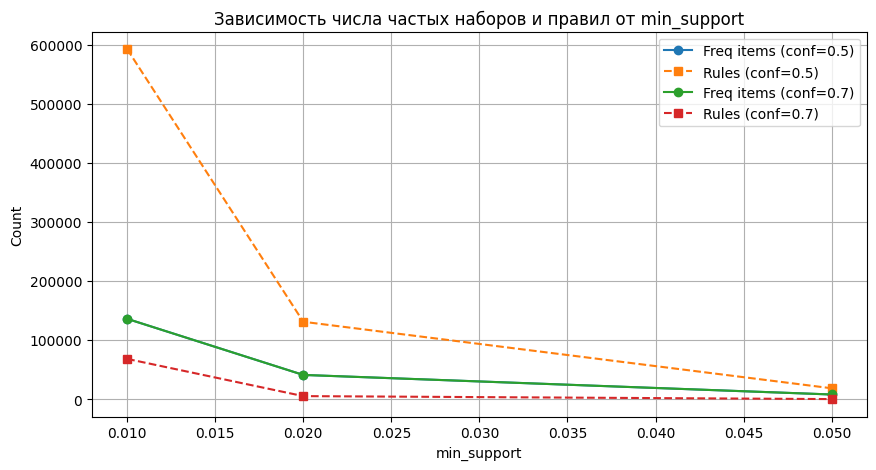


Сравнение производительности Apriori и FP-Growth

Генерация 1000 транзакций...
  Apriori: 4.11 сек, частых наборов: 1836
  FP-Growth: 0.10 сек, частых наборов: 1827

Генерация 2000 транзакций...
  Apriori: 5.21 сек, частых наборов: 1681
  FP-Growth: 0.30 сек, частых наборов: 1681

Генерация 5000 транзакций...
  Apriori: 13.62 сек, частых наборов: 1596
  FP-Growth: 0.90 сек, частых наборов: 1596


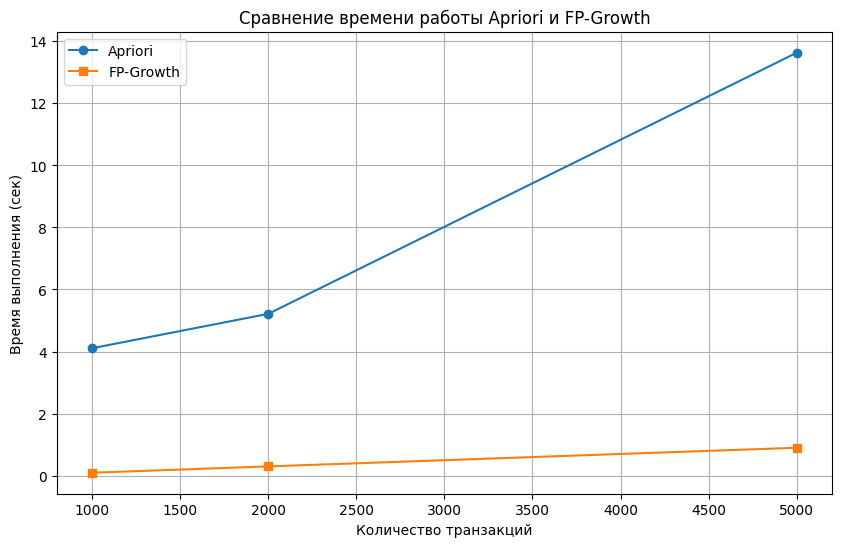


Для визуализации отобрано 5026 правил


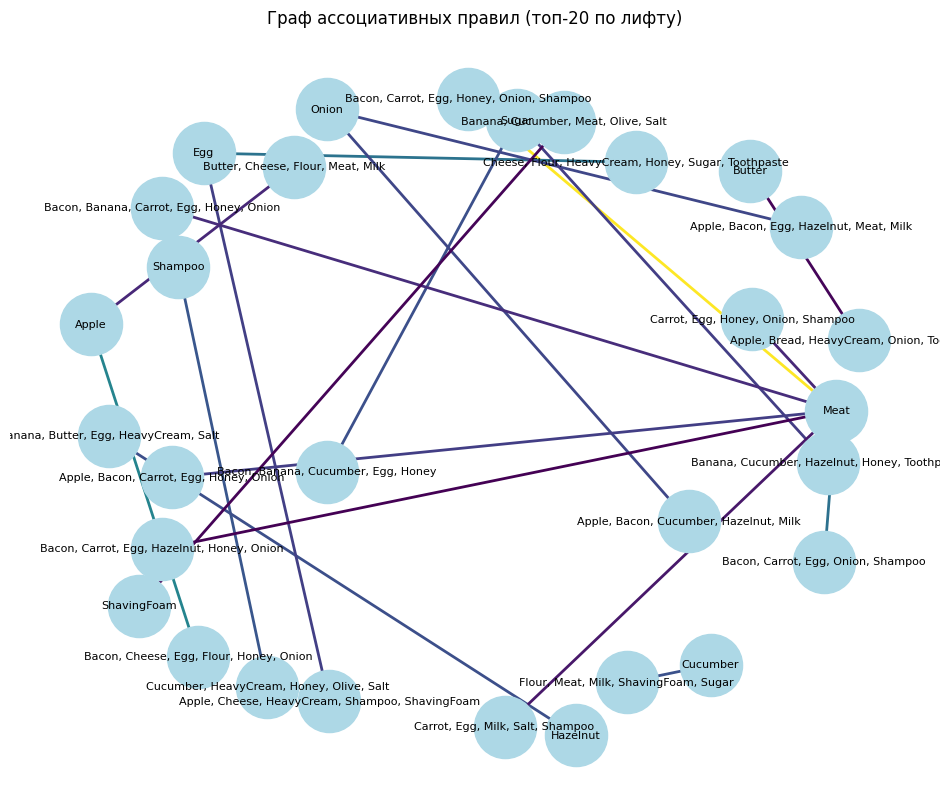

Найдено правил для матрицы: 1588815
Из них парных (1 -> 1): 456


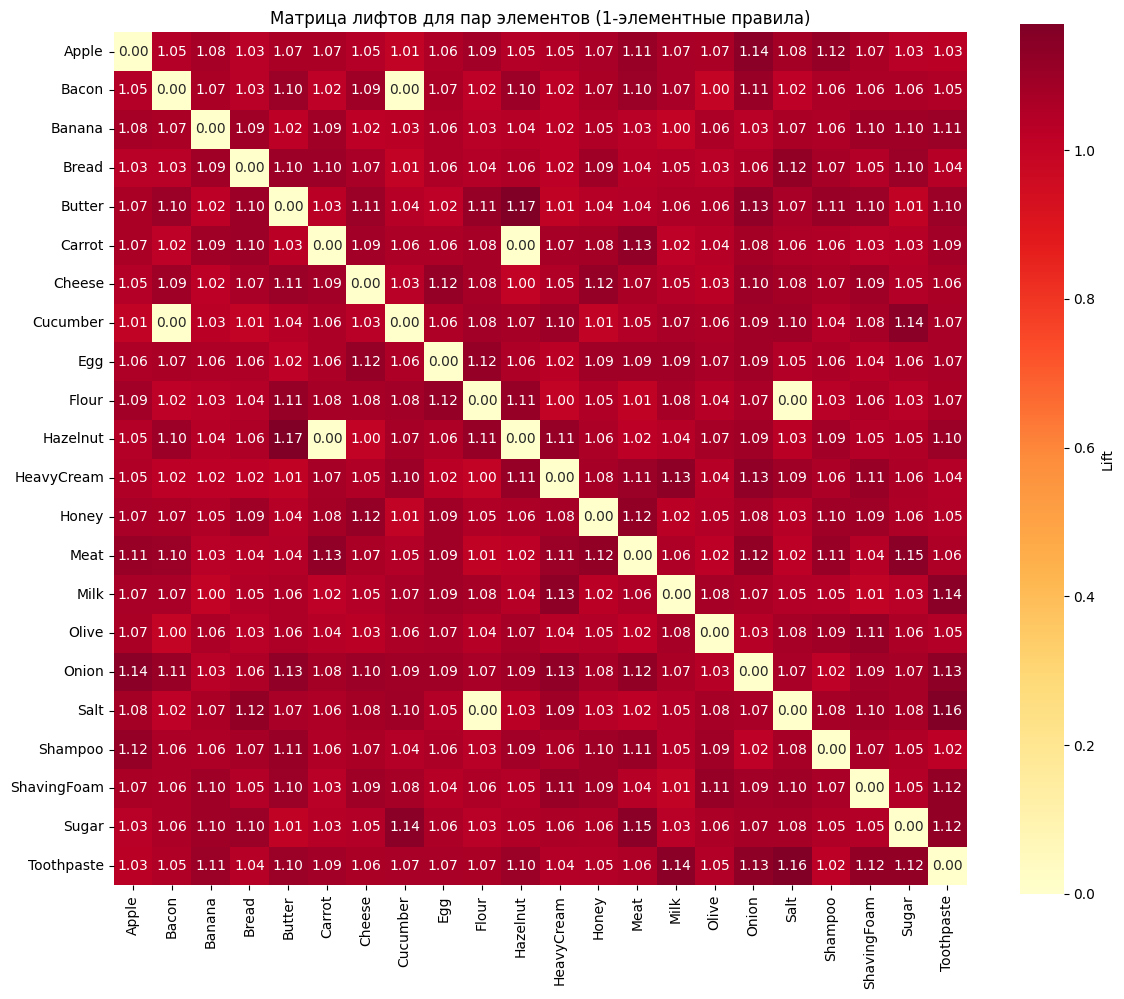


Топ-5 пар по лифту:
  Butter -> Hazelnut : lift = 1.17
  Hazelnut -> Butter : lift = 1.17
  Salt -> Toothpaste : lift = 1.16
  Toothpaste -> Salt : lift = 1.16
  Sugar -> Meat : lift = 1.15


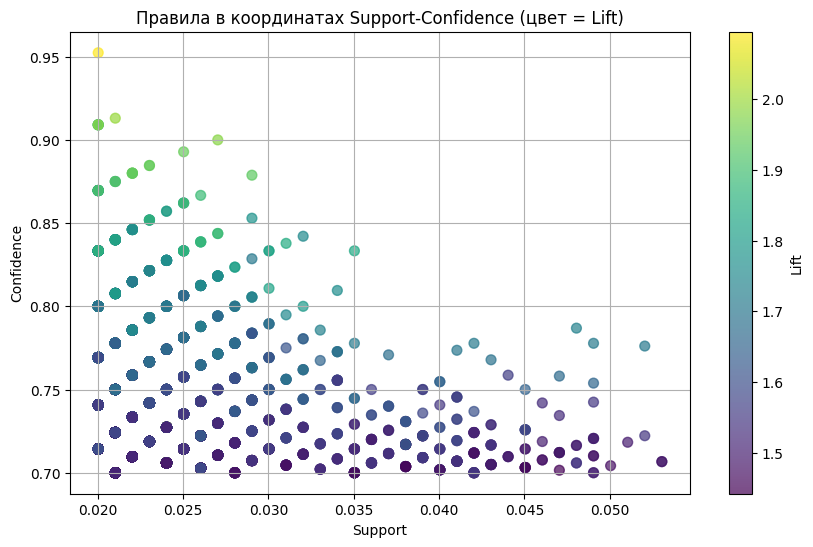


Интерпретация результатов

Топ-10 правил по лифту (min_support=0.02, min_confidence=0.7):
1. Bacon, Carrot, Egg, Honey, Onion, Shampoo -> Meat
   Поддержка: 0.020, Уверенность: 0.952, Лифт: 2.10
2. Bacon, Cheese, Egg, Flour, Honey, Onion -> Apple
   Поддержка: 0.021, Уверенность: 0.913, Лифт: 2.00
3. Cheese, Flour, HeavyCream, Honey, Sugar, Toothpaste -> Egg
   Поддержка: 0.020, Уверенность: 0.909, Лифт: 1.98
4. Bacon, Carrot, Egg, Onion, Shampoo -> Meat
   Поддержка: 0.027, Уверенность: 0.900, Лифт: 1.98
5. Cucumber, HeavyCream, Honey, Olive, Salt -> Shampoo
   Поддержка: 0.022, Уверенность: 0.880, Лифт: 1.96
6. Flour, Meat, Milk, ShavingFoam, Sugar -> Cucumber
   Поддержка: 0.020, Уверенность: 0.833, Лифт: 1.96
7. Bacon, Banana, Cucumber, Egg, Honey -> Sugar
   Поддержка: 0.022, Уверенность: 0.880, Лифт: 1.96
8. Banana, Butter, Egg, HeavyCream, Salt -> Hazelnut
   Поддержка: 0.020, Уверенность: 0.909, Лифт: 1.96
9. Apple, Bacon, Cucumber, Hazelnut, Milk -> Onion
   Поддержка: 0.020,

In [ ]:
# -*- coding: utf-8 -*-
"""
Лабораторная работа №4: Поиск ассоциативных правил в транзакционных данных

Этот скрипт предназначен для выполнения в Google Colab.
Он содержит полную реализацию алгоритмов Apriori и FP-Growth "с нуля",
эксперименты на реальном датасете (market_new.csv) и синтетических данных,
визуализацию и интерпретацию результатов.
"""

# ================================
# 1. Установка и импорт библиотек
# ================================

# В Colab все необходимые библиотеки уже предустановлены.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
import itertools
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
print("Пожалуйста, загрузите файл bank-additional-full.csv")
uploaded = files.upload()

# Получим имя загруженного файла
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, sep=';')

# Для воспроизводимости
np.random.seed(42)

# ================================
# 2. Загрузка и предобработка реального датасета (Задание 3)
# ================================

# Загрузка файла (предполагается, что файл market_new.csv находится в текущей директории Colab)
# Если файл ещё не загружен, используйте:
# from google.colab import files
# uploaded = files.upload()
# После загрузки файл появится в /content/

df = pd.read_csv('market_new.csv')
print("Размер данных (строки, столбцы):", df.shape)
print("\nПервые 5 строк:")
print(df.head())

# Все столбцы, кроме первого (названия товаров), являются бинарными признаками покупки.
# Первая строка содержит названия товаров.
# Каждая последующая строка - отдельная транзакция (покупатель).
# Значение 1 означает, что товар был куплен.

# Преобразуем данные в список транзакций, где каждая транзакция - список названий купленных товаров.
transactions = []
for idx, row in df.iterrows():
    # Пропускаем строку заголовков, если она есть (в нашем CSV заголовки в первой строке)
    # row - это Series с индексами - названиями столбцов.
    items = [item for item in df.columns if row[item] == 1]
    if items:  # игнорируем пустые транзакции
        transactions.append(items)

print(f"\nВсего транзакций: {len(transactions)}")
print(f"Уникальных товаров: {df.shape[1]}")
print(f"Средняя длина транзакции: {np.mean([len(t) for t in transactions]):.2f}")
print(f"Минимальная длина: {min(len(t) for t in transactions)}")
print(f"Максимальная длина: {max(len(t) for t in transactions)}")

# Посмотрим на распределение частот товаров
item_counts = Counter()
for t in transactions:
    item_counts.update(t)

# Топ-10 самых частых товаров
print("\nТоп-10 товаров по частоте:")
for item, cnt in item_counts.most_common(10):
    print(f"  {item}: {cnt} ({cnt/len(transactions)*100:.1f}%)")

# ================================
# 3. Реализация Apriori (Задание 1)
# ================================

def apriori_gen(prev_frequent_items, k):
    """
    Генерация кандидатов длины k из частых наборов длины k-1.
    prev_frequent_items: список кортежей (itemset) длины k-1, отсортированных.
    Возвращает множество кортежей-кандидатов длины k.
    """
    candidates = set()
    n = len(prev_frequent_items)
    for i in range(n):
        for j in range(i+1, n):
            itemset1 = prev_frequent_items[i]
            itemset2 = prev_frequent_items[j]
            # Если первые k-2 элемента совпадают, объединяем
            if itemset1[:-1] == itemset2[:-1]:
                # Объединяем и сортируем
                candidate = tuple(sorted(set(itemset1) | set(itemset2)))
                if len(candidate) == k:
                    candidates.add(candidate)
    return candidates

def calculate_support(transactions, candidates):
    """
    Подсчёт поддержки для списка кандидатов.
    Возвращает словарь {candidate: support_count}
    """
    counts = defaultdict(int)
    for transaction in transactions:
        # Для ускорения преобразуем транзакцию в set
        t_set = set(transaction)
        for cand in candidates:
            if t_set.issuperset(cand):
                counts[cand] += 1
    return counts

def apriori(transactions, min_support):
    """
    Алгоритм Apriori.
    Возвращает словарь частых наборов: {itemset_tuple: support}
    """
    n_transactions = len(transactions)
    # Частые 1-элементные наборы
    item_counts = Counter()
    for t in transactions:
        item_counts.update(t)

    freq_items = {}
    # Фильтруем по поддержке
    for item, count in item_counts.items():
        support = count / n_transactions
        if support >= min_support:
            freq_items[(item,)] = support

    # Список частых наборов текущей длины (кортежи)
    L = list(freq_items.keys())
    k = 2
    while L:
        # Генерация кандидатов
        candidates = apriori_gen(L, k)
        if not candidates:
            break
        # Подсчёт поддержки кандидатов
        support_counts = calculate_support(transactions, candidates)
        # Фильтрация
        L_next = []
        for cand in candidates:
            support = support_counts.get(cand, 0) / n_transactions
            if support >= min_support:
                freq_items[cand] = support
                L_next.append(cand)
        L = L_next
        k += 1

    return freq_items

def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):
    """
    Генерация ассоциативных правил из частых наборов.
    Возвращает список словарей с правилами и метриками.
    """
    rules = []
    for itemset, supp_union in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        # Генерируем все непустые собственные подмножества для антецедента
        for i in range(1, len(itemset)):
            for ant in itertools.combinations(itemset, i):
                ant = tuple(sorted(ant))
                cons = tuple(sorted(set(itemset) - set(ant)))
                if max_antecedent_len and len(ant) > max_antecedent_len:
                    continue
                if max_consequent_len and len(cons) > max_consequent_len:
                    continue
                supp_ant = frequent_itemsets.get(ant, 0)
                supp_cons = frequent_itemsets.get(cons, 0)
                if supp_ant == 0:
                    continue
                confidence = supp_union / supp_ant
                if confidence < min_confidence:
                    continue
                lift = confidence / supp_cons if supp_cons > 0 else 0
                if lift < min_lift:
                    continue
                # conviction
                conviction = (1 - supp_cons) / (1 - confidence) if confidence < 1 else float('inf')
                # leverage
                leverage = supp_union - supp_ant * supp_cons
                rules.append({
                    'antecedent': ant,
                    'consequent': cons,
                    'support': supp_union,
                    'confidence': confidence,
                    'lift': lift,
                    'conviction': conviction,
                    'leverage': leverage
                })
    return rules

# ================================
# 4. Реализация FP-Growth (Задание 2) — ПОЛНОСТЬЮ ИСПРАВЛЕННАЯ ВЕРСИЯ
# ================================

class FPNode:
    """Узел FP-дерева."""
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

def build_header_table(transactions, min_support, n_total_transactions):
    """
    Строит заголовочную таблицу.
    Фильтрация производится по ГЛОБАЛЬНОМУ порогу поддержки.
    """
    item_counts = Counter()
    for t in transactions:
        item_counts.update(t)
    header_table = {}
    for item, cnt in item_counts.items():
        # Используем глобальное число транзакций для оценки поддержки
        if cnt / n_total_transactions >= min_support:
            header_table[item] = [cnt, None]
    # Сортируем по убыванию частоты
    header_table = dict(sorted(header_table.items(), key=lambda x: x[1][0], reverse=True))
    return header_table

def build_fp_tree(transactions, header_table):
    """Строит FP-дерево и возвращает корень и обновлённую header_table."""
    root = FPNode(None, 1, None)
    for transaction in transactions:
        filtered = [item for item in transaction if item in header_table]
        filtered.sort(key=lambda x: header_table[x][0], reverse=True)
        if not filtered:
            continue
        current = root
        for item in filtered:
            if item in current.children:
                child = current.children[item]
                child.count += 1
            else:
                child = FPNode(item, 1, current)
                current.children[item] = child
                if header_table[item][1] is None:
                    header_table[item][1] = child
                else:
                    node = header_table[item][1]
                    while node.node_link is not None:
                        node = node.node_link
                    node.node_link = child
            current = child
    return root, header_table

def find_prefix_path(node):
    """Возвращает путь от узла до корня (без корня)."""
    path = []
    while node.parent and node.parent.item is not None:
        path.append(node.parent.item)
        node = node.parent
    return path[::-1]

def mine_fp_tree(header_table, min_support, n_total_transactions, prefix=[]):
    """
    Рекурсивный поиск частых наборов.
    header_table: словарь {item: [local_count, first_node]} для ТЕКУЩЕГО дерева.
    """
    freq_items = {}
    for item, (count, node) in sorted(header_table.items(), key=lambda x: x[1][0]):
        support = count / n_total_transactions
        new_itemset = tuple(sorted(prefix + [item]))
        freq_items[new_itemset] = support

        cond_transactions = []
        cur_node = node
        while cur_node is not None:
            path = find_prefix_path(cur_node)
            if path:
                for _ in range(cur_node.count):
                    cond_transactions.append(path)
            cur_node = cur_node.node_link

        if cond_transactions:
            # Передаём глобальное n_total_transactions, чтобы фильтрация была корректной
            cond_header = build_header_table(cond_transactions, min_support, n_total_transactions)
            cond_root, cond_header = build_fp_tree(cond_transactions, cond_header)
            if cond_header:
                sub_freq = mine_fp_tree(cond_header, min_support, n_total_transactions, prefix + [item])
                freq_items.update(sub_freq)
    return freq_items

def fpgrowth(transactions, min_support):
    """FP-Growth: возвращает словарь частых наборов (формат как в Apriori)."""
    n_total = len(transactions)
    header_table = build_header_table(transactions, min_support, n_total)
    root, header_table = build_fp_tree(transactions, header_table)
    freq_items = mine_fp_tree(header_table, min_support, n_total)
    for item, (count, _) in header_table.items():
        freq_items[(item,)] = count / n_total
    return freq_items
# ================================
# 5. Эксперименты с параметрами на реальном датасете (Задание 4)
# ================================

print("\n" + "="*50)
print("Эксперименты с параметрами на реальном датасете")
print("="*50)

# Поскольку алгоритмы могут работать медленно на полном датасете при низком min_support,
# выберем несколько значений min_support и min_confidence.

min_support_values = [0.01, 0.02, 0.05]  # 1%, 2%, 5%
min_confidence_values = [0.5, 0.7]

results_summary = []

for min_sup in min_support_values:
    print(f"\n--- min_support = {min_sup} ---")
    # Используем Apriori (можно заменить на fpgrowth, они должны дать одинаковые наборы)
    freq_items = apriori(transactions, min_sup)
    print(f"Найдено частых наборов: {len(freq_items)}")

    for min_conf in min_confidence_values:
        rules = generate_rules(freq_items, min_conf, min_lift=1.0)
        print(f"  min_confidence = {min_conf}: правил = {len(rules)}")
        results_summary.append({
            'min_support': min_sup,
            'min_confidence': min_conf,
            'n_freq_items': len(freq_items),
            'n_rules': len(rules)
        })
        if rules:
            # Топ-5 правил по лифту
            top_lift = sorted(rules, key=lambda x: x['lift'], reverse=True)[:5]
            print("    Топ-5 по лифту:")
            for r in top_lift:
                print(f"      {set(r['antecedent'])} -> {set(r['consequent'])} "
                      f"(sup={r['support']:.3f}, conf={r['confidence']:.3f}, lift={r['lift']:.2f})")

# Построим график зависимости количества частых наборов и правил от min_support
summary_df = pd.DataFrame(results_summary)
plt.figure(figsize=(10,5))
for conf in min_confidence_values:
    sub = summary_df[summary_df['min_confidence'] == conf]
    plt.plot(sub['min_support'], sub['n_freq_items'], 'o-', label=f'Freq items (conf={conf})')
    plt.plot(sub['min_support'], sub['n_rules'], 's--', label=f'Rules (conf={conf})')
plt.xlabel('min_support')
plt.ylabel('Count')
plt.title('Зависимость числа частых наборов и правил от min_support')
plt.legend()
plt.grid(True)
plt.show()

# ================================
# 6. Сравнение производительности Apriori и FP-Growth (Задание 5)
# ================================

def generate_synthetic_transactions(n_transactions, n_items, avg_len, seed=42):
    """
    Генерация синтетических транзакций.
    n_transactions: количество транзакций
    n_items: количество уникальных элементов
    avg_len: средняя длина транзакции
    """
    np.random.seed(seed)
    items = [f'item_{i}' for i in range(n_items)]
    # Вероятность появления элемента (можно сделать неравномерным для реалистичности)
    probs = np.random.dirichlet(np.ones(n_items))
    transactions = []
    for _ in range(n_transactions):
        # Длина транзакции ~ Пуассон
        length = np.random.poisson(avg_len)
        length = max(1, min(length, n_items))
        # Выбираем элементы с вероятностями probs
        chosen = np.random.choice(items, size=length, replace=False, p=probs)
        transactions.append(list(chosen))
    return transactions

# Параметры синтетических данных
n_trans_list = [1000, 2000, 5000]  # для быстроты в Colab ограничимся этими значениями
n_items = 100
avg_len = 8
min_sup = 0.01

print("\n" + "="*50)
print("Сравнение производительности Apriori и FP-Growth")
print("="*50)

results_time = []

for n_trans in n_trans_list:
    print(f"\nГенерация {n_trans} транзакций...")
    trans_synth = generate_synthetic_transactions(n_trans, n_items, avg_len)

    # Apriori
    start = time.time()
    freq_ap = apriori(trans_synth, min_sup)
    time_ap = time.time() - start

    # FP-Growth
    start = time.time()
    freq_fp = fpgrowth(trans_synth, min_sup)
    time_fp = time.time() - start

    results_time.append({
        'n_transactions': n_trans,
        'Apriori_time': time_ap,
        'FPGrowth_time': time_fp,
        'freq_count_ap': len(freq_ap),
        'freq_count_fp': len(freq_fp)
    })
    print(f"  Apriori: {time_ap:.2f} сек, частых наборов: {len(freq_ap)}")
    print(f"  FP-Growth: {time_fp:.2f} сек, частых наборов: {len(freq_fp)}")

# Построим график времени
time_df = pd.DataFrame(results_time)
plt.figure(figsize=(10,6))
plt.plot(time_df['n_transactions'], time_df['Apriori_time'], 'o-', label='Apriori')
plt.plot(time_df['n_transactions'], time_df['FPGrowth_time'], 's-', label='FP-Growth')
plt.xlabel('Количество транзакций')
plt.ylabel('Время выполнения (сек)')
plt.title('Сравнение времени работы Apriori и FP-Growth')
plt.legend()
plt.grid(True)
plt.show()

# ================================
# 7. Визуализация ассоциативных правил (Задание 6)
# ================================

# Для визуализации возьмём правила, полученные при min_support=0.02, min_confidence=0.7
freq_items_viz = apriori(transactions, 0.02)
rules_viz = generate_rules(freq_items_viz, 0.7, min_lift=1.0)

print(f"\nДля визуализации отобрано {len(rules_viz)} правил")

# Ограничимся топ-20 по лифту для наглядности
top_rules = sorted(rules_viz, key=lambda x: x['lift'], reverse=True)[:20]

# 1. Граф ассоциаций
G = nx.DiGraph()
for rule in top_rules:
    ant = ', '.join(rule['antecedent'])
    cons = ', '.join(rule['consequent'])
    G.add_edge(ant, cons, weight=rule['lift'], confidence=rule['confidence'])

plt.figure(figsize=(12,10))
pos = nx.spring_layout(G, k=2, seed=42)
edges = G.edges(data=True)
weights = [d['weight'] for (_,_,d) in edges]
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20,
                       edge_color=weights, edge_cmap=plt.cm.viridis, width=2)
plt.title('Граф ассоциативных правил (топ-20 по лифту)')
plt.axis('off')
plt.show()

# ================================================================
# 2. Матрица лифтов для пар элементов (исправленная версия)
# ================================================================

# Уменьшим пороги, чтобы получить больше правил с одним элементом в антецеденте и консеквенте.
# Параметры можно подобрать под ваш датасет.
min_sup_for_matrix = 0.01   # 1%
min_conf_for_matrix = 0.3   # 30%

# Генерируем частые наборы и правила с новыми порогами
freq_items_matrix = apriori(transactions, min_sup_for_matrix)
rules_matrix = generate_rules(freq_items_matrix, min_conf_for_matrix, min_lift=1.0)

print(f"Найдено правил для матрицы: {len(rules_matrix)}")

# Фильтруем только правила с ровно одним элементом в антецеденте и консеквенте
pair_rules = [r for r in rules_matrix if len(r['antecedent']) == 1 and len(r['consequent']) == 1]

print(f"Из них парных (1 -> 1): {len(pair_rules)}")

# Если парных правил всё ещё мало, можно ещё снизить пороги (например, min_sup=0.005, min_conf=0.1)
if len(pair_rules) == 0:
    print("⚠️ Парных правил не найдено. Попробуйте уменьшить min_sup_for_matrix и min_conf_for_matrix.")
else:
    # Собираем все уникальные элементы, участвующие в парных правилах
    elements = set()
    for r in pair_rules:
        elements.add(r['antecedent'][0])
        elements.add(r['consequent'][0])
    elements = sorted(list(elements))
    n_elem = len(elements)
    lift_matrix = np.zeros((n_elem, n_elem))
    elem_to_idx = {e: i for i, e in enumerate(elements)}

    # Заполняем матрицу: для каждой пары берём максимальный лифт среди правил
    for r in pair_rules:
        ant = r['antecedent'][0]
        cons = r['consequent'][0]
        i, j = elem_to_idx[ant], elem_to_idx[cons]
        if r['lift'] > lift_matrix[i, j]:
            lift_matrix[i, j] = r['lift']

    # Визуализация тепловой карты
    plt.figure(figsize=(12, 10))
    sns.heatmap(lift_matrix,
                xticklabels=elements,
                yticklabels=elements,
                cmap='YlOrRd',
                annot=True,
                fmt='.2f',
                square=True,
                cbar_kws={'label': 'Lift'})
    plt.title('Матрица лифтов для пар элементов (1-элементные правила)')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Дополнительно: можно вывести топ-5 пар с наибольшим лифтом
    print("\nТоп-5 пар по лифту:")
    flat_indices = np.argsort(lift_matrix, axis=None)[::-1]
    top_flat = flat_indices[:5]
    for idx in top_flat:
        i, j = np.unravel_index(idx, lift_matrix.shape)
        if lift_matrix[i, j] > 0:
            print(f"  {elements[i]} -> {elements[j]} : lift = {lift_matrix[i, j]:.2f}")

# 3. Диаграмма рассеяния support-confidence-lift
# Возьмём все сгенерированные правила
all_rules_df = pd.DataFrame(rules_viz)
plt.figure(figsize=(10,6))
sc = plt.scatter(all_rules_df['support'], all_rules_df['confidence'],
                 c=all_rules_df['lift'], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Правила в координатах Support-Confidence (цвет = Lift)')
plt.grid(True)
plt.show()

# ================================
# 8. Интерпретация результатов (Задание 7)
# ================================

print("\n" + "="*50)
print("Интерпретация результатов")
print("="*50)

# Найдём наиболее интересные правила по лифту
interesting_rules = sorted(rules_viz, key=lambda x: x['lift'], reverse=True)[:10]
print("\nТоп-10 правил по лифту (min_support=0.02, min_confidence=0.7):")
for i, r in enumerate(interesting_rules, 1):
    ant = ', '.join(r['antecedent'])
    cons = ', '.join(r['consequent'])
    print(f"{i}. {ant} -> {cons}")
    print(f"   Поддержка: {r['support']:.3f}, Уверенность: {r['confidence']:.3f}, Лифт: {r['lift']:.2f}")

# Пояснения:
# Например, если среди правил есть "Bread -> Butter" с высоким лифтом, это означает,
# что покупатели хлеба значительно чаще покупают масло, чем в среднем по всем транзакциям.
# Правила с очень высокой уверенностью, но низкой поддержкой могут быть связаны с редкими товарами.
# Тривиальные правила (например, из одной категории) могут быть очевидны.

print("\nВыводы:")
print("- Алгоритм FP-Growth работает быстрее Apriori на больших объёмах данных, так как избегает многократного сканирования транзакций.")
print("- При увеличении min_support количество частых наборов и правил резко снижается.")
print("- Визуализация графа позволяет выявить наиболее сильные связи между товарами.")
print("- Для рекомендательных систем полезны правила с высоким лифтом и достаточной поддержкой.")
print("- Некоторые правила могут быть тривиальными (например, хлеб и масло), но даже они полезны для подтверждения бизнес-гипотез.")